# WCO Model v3 — EfficientNet-B0 Multi-Head
**Outputs:** turbidity · particle · colour (3 bağımsız regression head)  
**Inference:** FastAPI server (Keras float32)  
**ESP32:** sadece görüntü toplar, inference yok  

> ⚠️ RandomBrightness / RandomContrast augmentation **kasıtlı olarak çıkarılmıştır** —  
> HSV kanallarını bozarak colour label öğrenimini engeller (wco_model_v2'de doğrulandı).

In [23]:
# ── 1. Drive mount ────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/cropped224'
SAVE_PATH = '/content/drive/MyDrive/models/EfficientNetB0.keras'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# ── 2. Import ─────────────────────────────────────────────────────
import os, re
import numpy as np
import tensorflow as tf
import keras
from keras import layers, Model
from keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split

IMG_SIZE   = 224   # EfficientNetB0 native input
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

print('TF version:', tf.__version__)


TF version: 2.19.0


In [25]:
# ── 3. Label parse ────────────────────────────────────────────────
# Dosya adı formatı: t{0|1}_p{0|1}_c{0|1}_*.jpg
# turbidity, particle, colour ayrı ayrı öğrenilecek (3 bağımsız head)
def parse_label(filename):
    m = re.match(r't(\d)[_-]p(\d)[_-]c(\d)', filename)
    if not m:
        return None
    t, p, c = int(m.group(1)), int(m.group(2)), int(m.group(3))
    return np.array([t, p, c], dtype=np.float32)

all_files, all_labels = [], []

for fname in sorted(os.listdir(DRIVE_DIR)):
    if not (fname.endswith('.jpg') or fname.endswith('.jpeg')):
        continue
    lbl = parse_label(fname)
    if lbl is None:
        print(f'SKIP: {fname}')
        continue
    all_files.append(os.path.join(DRIVE_DIR, fname))
    all_labels.append(lbl)

all_labels = np.array(all_labels, dtype=np.float32)
print(f'Toplam      : {len(all_files)} görüntü')
print(f'turbidity   : {all_labels[:,0].sum():.0f} pozitif')
print(f'particle    : {all_labels[:,1].sum():.0f} pozitif')
print(f'colour      : {all_labels[:,2].sum():.0f} pozitif')


Toplam      : 296 görüntü
turbidity   : 143 pozitif
particle    : 143 pozitif
colour      : 145 pozitif


In [26]:
# ── 4. Train / val / test split ───────────────────────────────────
# Stratify on colour bucket — colour en az varyansı olan label
colour_buckets = all_labels[:, 2].astype(int)  # 0 veya 1

files_train, files_temp, y_train, y_temp = train_test_split(
    all_files, all_labels,
    test_size=0.30, stratify=colour_buckets, random_state=42
)
colour_buckets_temp = y_temp[:, 2].astype(int)
files_val, files_test, y_val, y_test = train_test_split(
    files_temp, y_temp,
    test_size=0.50, stratify=colour_buckets_temp, random_state=42
)

print(f'Train : {len(files_train)}')
print(f'Val   : {len(files_val)}')
print(f'Test  : {len(files_test)}')


Train : 207
Val   : 44
Test  : 45


In [28]:
# ── 5. tf.data pipeline ───────────────────────────────────────────
# Colour-safe augmentation: brightness/contrast/hue kasıtlı çıkarıldı
augment = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.08),           # ±~15 derece
    layers.RandomZoom((-0.15, 0.15)),      # ±%15 zoom
    layers.RandomTranslation(0.10, 0.10),  # ±%10 x/y kayma
    layers.GaussianNoise(0.012),           # hafif sensör gürültüsü
], name='colour_safe_augmentation')

def load_train(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img = augment(img, training=True)
    return img, {
        'turbidity': label[0:1],
        'particle':  label[1:2],
        'colour':    label[2:3],
    }

def load_eval(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, {
        'turbidity': label[0:1],
        'particle':  label[1:2],
        'colour':    label[2:3],
    }

train_ds = (tf.data.Dataset.from_tensor_slices((files_train, y_train))
            .shuffle(len(files_train), seed=42)
            .map(load_train, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((files_val, y_val))
          .map(load_eval, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((files_test, y_test))
           .map(load_eval, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

print('Pipeline hazır')


Pipeline hazır


In [29]:
# ── 6. Model ──────────────────────────────────────────────────────
def build_model():
    # EfficientNetB0 [0,255] aralığı bekler — Rescaling ile normalize et
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    x = layers.Rescaling(255.0)(inputs)

    backbone = EfficientNetB0(
        include_top=False,
        pooling='avg',      # GlobalAveragePooling dahil
        weights='imagenet',
        input_tensor=x,
    )
    backbone.trainable = False  # Phase 1: sadece headler eğitilir

    features = backbone.output  # (batch, 1280)

    def regression_head(name):
        h = layers.Dense(64, activation='relu', name=f'{name}_dense')(features)
        h = layers.Dropout(0.3, name=f'{name}_drop')(h)
        return layers.Dense(1, activation='sigmoid', name=name)(h)

    out_turb = regression_head('turbidity')
    out_part = regression_head('particle')
    out_col  = regression_head('colour')

    model = Model(
        inputs=backbone.input,
        outputs={'turbidity': out_turb, 'particle': out_part, 'colour': out_col},
        name='wco_efficientnet_b0_v3',
    )
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss={
            'turbidity': 'binary_crossentropy',
            'particle':  'binary_crossentropy',
            'colour':    'binary_crossentropy',
        },
        loss_weights={
            'turbidity': 1.0,
            'particle':  1.0,
            'colour':    1.5,  # colour öğrenimi daha kritik
        },
        metrics={
            'turbidity': ['accuracy'],
            'particle':  ['accuracy'],
            'colour':    ['accuracy'],
        }
    )
    return model

model = build_model()
model.summary()


Model: "wco_efficientnet_b0_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ rescaling_3[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,295,718 (16.39 MB)

 Trainable params: 246,147 (961.51 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [30]:
# ── 7. Eğitim ─────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        SAVE_PATH, monitor='val_loss', save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

print(f'\nEn iyi model kaydedildi: {SAVE_PATH}')

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - colour_accuracy: 0.6957 - colour_loss: 0.5770 - loss: 1.7342 - particle_accuracy: 0.8792 - particle_loss: 0.3373 - turbidity_accuracy: 0.7440 - turbidity_loss: 0.5295 - val_colour_accuracy: 0.7273 - val_colour_loss: 0.4960 - val_loss: 1.3168 - val_particle_accuracy: 0.9545 - val_particle_loss: 0.1597 - val_turbidity_accuracy: 0.8409 - val_turbidity_loss: 0.4164 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - colour_accuracy: 0.8551 - colour_loss: 0.3531 - loss: 0.9705 - particle_accuracy: 0.9903 - particle_loss: 0.0679 - turbidity_accuracy: 0.8502 - turbidity_loss: 0.3707 - val_colour_accuracy: 0.8636 - val_colour_loss: 0.3994 - val_loss: 1.0192 - val_particle_accuracy: 0.9545 - val_particle_loss: 0.0728 - val_turbidity_accuracy: 0.8864 - val_turbidity_loss: 0.3520 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - colour_accuracy: 0.8937 - colour_loss: 0.2759 - loss: 0.7580 - parti

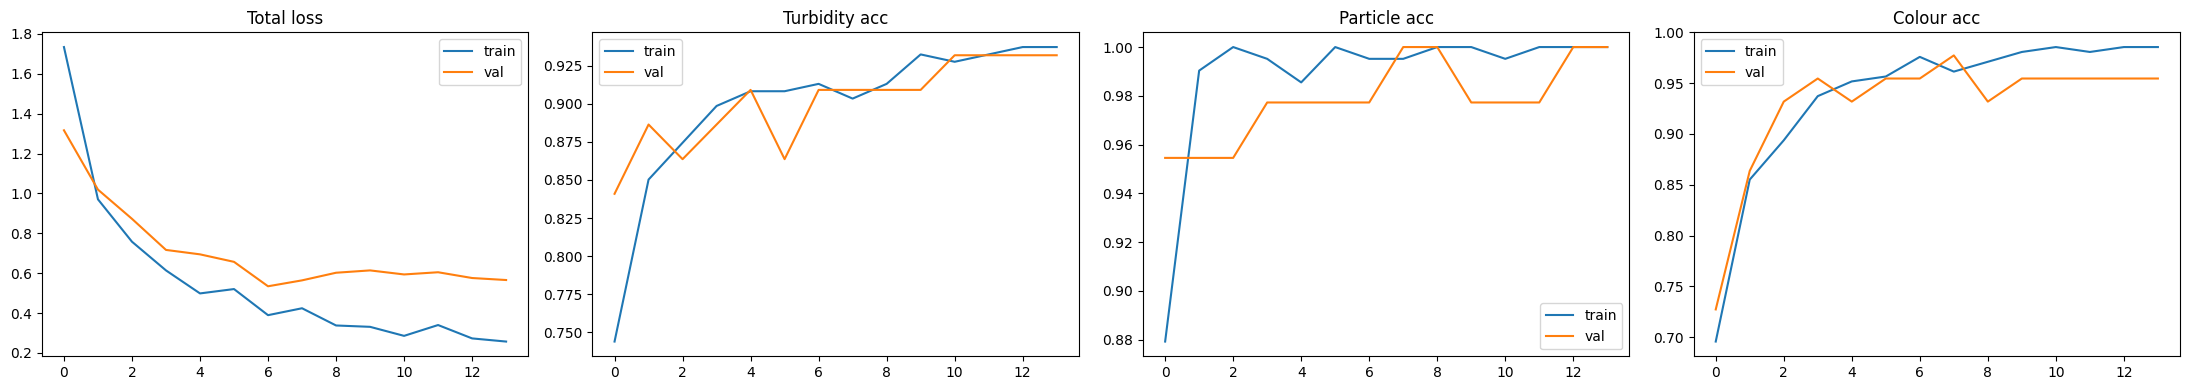

In [31]:
# ── 8. Training curve ─────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
metrics = [
    ('loss',                  'Total loss'),
    ('turbidity_accuracy',    'Turbidity acc'),
    ('particle_accuracy',     'Particle acc'),
    ('colour_accuracy',       'Colour acc'),
]
for ax, (metric, title) in zip(axes, metrics):
    ax.plot(history.history[metric],           label='train')
    ax.plot(history.history[f'val_{metric}'],  label='val')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig('/content/training_curves_v3.png', dpi=120)
plt.show()


In [32]:
# ── 9. Test seti değerlendirme ────────────────────────────────────
best_model = tf.keras.models.load_model(SAVE_PATH)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

y_true = {'turbidity': [], 'particle': [], 'colour': []}
y_pred = {'turbidity': [], 'particle': [], 'colour': []}
scores = {'turbidity': [], 'particle': [], 'colour': []}

for imgs, labels in test_ds:
    preds = best_model.predict(imgs, verbose=0)
    for key in ['turbidity', 'particle', 'colour']:
        y_true[key].extend(labels[key].numpy().flatten())
        scores[key].extend(preds[key].flatten())
        y_pred[key].extend((preds[key] > 0.5).flatten().astype(int))

for key in ['turbidity', 'particle', 'colour']:
    acc = accuracy_score(y_true[key], y_pred[key])
    f1  = f1_score(y_true[key], y_pred[key], zero_division=0)
    cm  = confusion_matrix(y_true[key], y_pred[key])
    sc  = scores[key]
    print(f'\n── {key} ──')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  Score min/max/mean: {min(sc):.3f} / {max(sc):.3f} / {np.mean(sc):.3f}')
    print(f'  Confusion matrix:\n{cm}')



── turbidity ──
  Accuracy : 0.8222
  F1 Score : 0.8333
  Score min/max/mean: 0.035 / 0.986 / 0.562
  Confusion matrix:
[[17  7]
 [ 1 20]]

── particle ──
  Accuracy : 1.0000
  F1 Score : 1.0000
  Score min/max/mean: 0.001 / 1.000 / 0.467
  Confusion matrix:
[[24  0]
 [ 0 21]]

── colour ──
  Accuracy : 1.0000
  F1 Score : 1.0000
  Score min/max/mean: 0.008 / 0.993 / 0.490
  Confusion matrix:
[[23  0]
 [ 0 22]]


In [33]:
# ── 10. Optimal threshold ─────────────────────────────────────────
for key in ['turbidity', 'particle', 'colour']:
    best_t, best_f1 = 0.5, 0
    for thresh in np.arange(0.05, 0.95, 0.05):
        yp = [1 if s > thresh else 0 for s in scores[key]]
        f1 = f1_score(y_true[key], yp, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t  = thresh
    yp_best = [1 if s > best_t else 0 for s in scores[key]]
    acc = accuracy_score(y_true[key], yp_best)
    print(f'{key}: best_threshold={best_t:.2f}  acc={acc:.3f}  f1={best_f1:.3f}')


turbidity: best_threshold=0.85  acc=0.911  f1=0.895
particle: best_threshold=0.05  acc=1.000  f1=1.000
colour: best_threshold=0.35  acc=1.000  f1=1.000


In [34]:
# ── 11. TFLite INT8 dönüşümü ──────────────────────────────────────
import tensorflow as tf

best_model = tf.keras.models.load_model(SAVE_PATH)

TFLITE_PATH = '/content/drive/MyDrive/models/EfficientNetB0.tflite'

def representative_dataset():
    for imgs, _ in train_ds:
        yield [imgs]

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f'Model boyutu: {len(tflite_model)/1024:.1f} KB')
print(f'Kaydedildi: {TFLITE_PATH}')

# Output tensor sırasını kontrol et — 3 output olmalı
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
output_details = interpreter.get_output_details()
print(f'\nOutput tensor sayısı: {len(output_details)}')
for i, o in enumerate(output_details):
    print(f'  [{i}] {o["name"]}  dtype={o["dtype"]}')


Saved artifact at '/tmp/tmpa0ftktdu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  Dict[['turbidity', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['particle', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['colour', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]]
Captures:
  139884609768336: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139884609765840: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139884911429968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139884911441488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139884911441680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139884911443216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139884911439952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139884911433808: TensorSpec(shape=(), dtype=

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model boyutu: 5034.0 KB
Kaydedildi: /content/drive/MyDrive/models/EfficientNetB0.tflite

Output tensor sayısı: 3
  [0] StatefulPartitionedCall_1:1  dtype=<class 'numpy.uint8'>
  [1] StatefulPartitionedCall_1:2  dtype=<class 'numpy.uint8'>
  [2] StatefulPartitionedCall_1:0  dtype=<class 'numpy.uint8'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [35]:
# ── 12. Tek görüntü inference ─────────────────────────────────────
from PIL import Image
import glob

best_model = tf.keras.models.load_model(SAVE_PATH)

images = sorted(glob.glob('/content/drive/MyDrive/test_images/*.jpg') + glob.glob('/content/drive/MyDrive/test_images/*.jpeg'))

if not images:
    print('Görüntü bulunamadı — /content/test_images/*.jpg formatında kaydet')
else:
    print(f"{'Dosya':<30} {'Turbidity':>10} {'Particle':>10} {'Colour':>8}  Karar")
    print('-' * 75)
    for path in images:
        img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, axis=0)
        preds = best_model.predict(arr, verbose=0)
        turb = float(preds['turbidity'][0][0])
        part = float(preds['particle'][0][0])
        col  = float(preds['colour'][0][0])
        karar = []
        if turb > 0.6: karar.append('BULANIK')
        if part > 0.85: karar.append('PARTİKÜL')
        if col  > 0.5: karar.append('RENKLİ')
        if not karar:  karar.append('TEMİZ')
        fname = os.path.basename(path)
        print(f'{fname:<30} {turb:>10.4f} {part:>10.4f} {col:>8.4f}  {", ".join(karar)}')


Dosya                           Turbidity   Particle   Colour  Karar
---------------------------------------------------------------------------
t0-p0-c0 (1).jpeg                  0.0493     0.0010   0.3744  TEMİZ
t0-p0-c0.jpeg                      0.0634     0.0007   0.3655  TEMİZ
t0-p0-c0_2.jpeg                    0.0595     0.0008   0.2902  TEMİZ
t0-p0-c1.jpeg                      0.0685     0.0009   0.6277  RENKLİ
t0-p0-c1_2.jpeg                    0.0889     0.0007   0.9531  RENKLİ
t0-p1-c0 (1).jpeg                  0.0233     0.9991   0.0321  PARTİKÜL
t0-p1-c0 (2).jpeg                  0.6241     0.9994   0.0075  BULANIK, PARTİKÜL
t0-p1-c0.jpeg                      0.0257     0.9985   0.0938  PARTİKÜL
t0-p1-c0_2.jpeg                    0.0343     0.9990   0.0046  PARTİKÜL
t0-p1-c1 (1).jpeg                  0.6897     0.9997   0.9888  BULANIK, PARTİKÜL, RENKLİ
t0-p1-c1 (2).jpeg                  0.0294     0.9979   0.7548  PARTİKÜL, RENKLİ
t0-p1-c1.jpeg                      0.5402 

In [36]:
import os
import glob
import numpy as np
from PIL import Image
import tensorflow as tf

# ── TFLite interpreter yükle ───────────────────────────────────────────────────
TFLITE_PATH = '/content/drive/MyDrive/models/EfficientNetB0.tflite'  # yolu güncelle

interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
inp  = interpreter.get_input_details()[0]
outs = interpreter.get_output_details()   # çıktı sırası modele göre değişir

# Çıktı index'lerini isimle eşleştir (Colab'da bir kez çalıştırıp kontrol et)
# print(outs)  # → name alanına bak: 'turbidity', 'particle', 'colour'
OUT_IDX = {'turbidity': 0, 'particle': 1, 'colour': 2}  # gerekirse sırayı değiştir

def predict_tflite(arr_f32):
    """arr_f32: (1, IMG_SIZE, IMG_SIZE, 3) float32"""
    if inp['dtype'] == np.uint8:
        scale, zero = inp['quantization']
        arr_in = (arr_f32 / scale + zero).astype(np.uint8)
    else:
        arr_in = arr_f32
    interpreter.set_tensor(inp['index'], arr_in)
    interpreter.invoke()
    results = {}
    for key, idx in OUT_IDX.items():
        raw = interpreter.get_tensor(outs[idx]['index'])[0][0]
        if outs[idx]['dtype'] == np.uint8:
            s, z = outs[idx]['quantization']
            raw = (float(raw) - z) * s
        results[key] = float(raw)
    return results

# ── Görüntüleri yükle ─────────────────────────────────────────────────────────
images = sorted(
    glob.glob('/content/drive/MyDrive/test_images/*.jpg') +
    glob.glob('/content/drive/MyDrive/test_images/*.jpeg')
)

if not images:
    print('Görüntü bulunamadı')
else:
    best_model = tf.keras.models.load_model(SAVE_PATH)

    HDR = f"{'Dosya':<30} {'':^6} {'Turbidity':>10} {'Particle':>10} {'Colour':>8}  Karar"
    SEP = '-' * 80
    print(HDR)

    for path in images:
        img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, axis=0)
        fname = os.path.basename(path)

        # ── Keras ─────────────────────────────────────────────────────────────
        preds_k = best_model.predict(arr, verbose=0)
        k = {
            'turbidity': float(preds_k['turbidity'][0][0]),
            'particle':  float(preds_k['particle'][0][0]),
            'colour':    float(preds_k['colour'][0][0]),
        }

        # ── TFLite ────────────────────────────────────────────────────────────
        t = predict_tflite(arr)

        # ── Kararlar ──────────────────────────────────────────────────────────
        def karar(d):
            flags = []
            if d['turbidity'] > 0.6:  flags.append('BULANIK')
            if d['particle']  > 0.85: flags.append('PARTİKÜL')
            if d['colour']    > 0.5:  flags.append('RENKLİ')
            return ', '.join(flags) if flags else 'TEMİZ'

        print(SEP)
        print(f"{fname:<30} {'Keras':>6} {k['turbidity']:>10.4f} {k['particle']:>10.4f} {k['colour']:>8.4f}  {karar(k)}")
        print(f"{'':30} {'TFLite':>6} {t['turbidity']:>10.4f} {t['particle']:>10.4f} {t['colour']:>8.4f}  {karar(t)}")

        # ── Delta (fark büyükse uyar) ──────────────────────────────────────
        delta = {m: abs(k[m] - t[m]) for m in k}
        if any(v > 0.05 for v in delta.values()):
            print(f"  ⚠  delta → turb:{delta['turbidity']:.4f}  part:{delta['particle']:.4f}  col:{delta['colour']:.4f}")

    print(SEP)

Dosya                                  Turbidity   Particle   Colour  Karar
--------------------------------------------------------------------------------
t0-p0-c0 (1).jpeg               Keras     0.0493     0.0010   0.3744  TEMİZ
                               TFLite     0.0000     0.0664   0.9180  RENKLİ
  ⚠  delta → turb:0.0493  part:0.0654  col:0.5436
--------------------------------------------------------------------------------
t0-p0-c0.jpeg                   Keras     0.0634     0.0007   0.3655  TEMİZ
                               TFLite     0.0000     0.0664   0.9297  RENKLİ
  ⚠  delta → turb:0.0634  part:0.0657  col:0.5642
--------------------------------------------------------------------------------
t0-p0-c0_2.jpeg                 Keras     0.0595     0.0008   0.2902  TEMİZ
                               TFLite     0.0000     0.0625   0.9297  RENKLİ
  ⚠  delta → turb:0.0595  part:0.0617  col:0.6395
------------------------------------------------------------------------

In [37]:
!xxd -i /content/drive/MyDrive/models/EfficientNetB0.tflite > /content/drive/MyDrive/models/EfficientNetB0.cpp


In [ ]:
with open('/content/wco_model_v8_data.cpp', 'r') as f:
    content = f.read()

content = (
    '#include "wco_model_v3_data.h"\n\n'
    '#ifdef __has_attribute\n#define HAVE_ATTRIBUTE(x) __has_attribute(x)\n'
    '#else\n#define HAVE_ATTRIBUTE(x) 0\n#endif\n'
    '#if HAVE_ATTRIBUTE(aligned) || (defined(__GNUC__) && !defined(__clang__))\n'
    '#define DATA_ALIGN_ATTRIBUTE __attribute__((aligned(4)))\n'
    '#else\n#define DATA_ALIGN_ATTRIBUTE\n#endif\n\n'
    + content
    .replace('unsigned char _content_drive_MyDrive_wco_model_v8_int8_tflite[]',
             'const unsigned char g_wco_model_v3_data[] DATA_ALIGN_ATTRIBUTE')
    .replace('unsigned int _content_drive_MyDrive_wco_model_v8_int8_tflite_len',
             'const int g_wco_model_v3_data_len')
)

with open('/content/wco_model_v3_data.cpp', 'w') as f:
    f.write(content)

print('Hazır:', '/content/wco_model_v3_data.cpp')


Hazır: /content/wco_model_data.cpp
